# 10 — Uncertainty analysis

**Goal:** Estimate uncertainty of model predictions using **ensemble variability**.

We train multiple models (LightGBM, RandomForest, XGBoost), compute predictions from each, then use the **spread** across models as an uncertainty proxy: **mean_prediction** and **prediction_std**. We visualize uncertainty, compare it to prediction error, and interpret regions of unreliable predictions.

# 1. Train ensemble models

Load the dataset (same preprocessing as in previous notebooks). Train **LightGBM**, **RandomForest**, and **XGBoost** (if available) on the full data for target **total_alkalinity**.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT))

from src.features.preprocess import feature_columns, impute_median

RAW = ROOT / "data" / "raw"
csv_path = RAW / "water_quality_dataset_v1.csv"
if not csv_path.exists():
    csv_path = RAW / "water_quality.csv"
if not csv_path.exists():
    raise FileNotFoundError("No water_quality_dataset_v1.csv or water_quality.csv in data/raw.")

df = pd.read_csv(csv_path)
if "Latitude" in df.columns and "lat" not in df.columns:
    df["lat"] = df["Latitude"]
if "Longitude" in df.columns and "lon" not in df.columns:
    df["lon"] = df["Longitude"]
for old, new in [("Total Alkalinity", "total_alkalinity"), ("Electrical Conductance", "electrical_conductance"), ("Dissolved Reactive Phosphorus", "dissolved_reactive_phosphorus")]:
    if old in df.columns and new not in df.columns:
        df[new] = df[old]

TARGET = "total_alkalinity"
if TARGET not in df.columns:
    TARGET = [c for c in ["total_alkalinity", "electrical_conductance", "dissolved_reactive_phosphorus"] if c in df.columns][0]

cols = feature_columns(df, exclude_targets=True)
X = df[cols].copy()
X, _ = impute_median(X)
y = df[TARGET].values
lat_arr = np.asarray(df["lat"] if "lat" in df.columns else df["Latitude"], dtype=float)
lon_arr = np.asarray(df["lon"] if "lon" in df.columns else df["Longitude"], dtype=float)

RANDOM_STATE = 42
scaler = StandardScaler().fit(X)
X_scaled = pd.DataFrame(scaler.transform(X), columns=cols)

models = []
model_names = []

try:
    import lightgbm as lgb
    models.append(lgb.LGBMRegressor(n_estimators=150, max_depth=6, random_state=RANDOM_STATE, verbose=-1))
    model_names.append("LightGBM")
except ImportError:
    pass

from sklearn.ensemble import RandomForestRegressor
models.append(RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE))
model_names.append("RandomForest")

try:
    import xgboost as xgb
    models.append(xgb.XGBRegressor(n_estimators=150, max_depth=6, random_state=RANDOM_STATE))
    model_names.append("XGBoost")
except ImportError:
    pass

for m, name in zip(models, model_names):
    m.fit(X_scaled, y)
print(f"Trained {len(models)} models: {model_names}")

Trained 3 models: ['LightGBM', 'RandomForest', 'XGBoost']


# 2. Generate predictions

For each model, compute predictions on the dataset. Store in a matrix (n_samples × n_models).

In [2]:
preds = np.column_stack([m.predict(X_scaled) for m in models])
print(f"Predictions shape: {preds.shape} (n_samples × n_models)")

Predictions shape: (9319, 3) (n_samples × n_models)


# 3. Estimate uncertainty

Compute **mean_prediction** (mean across models) and **prediction_std** (standard deviation across models) as a proxy for prediction uncertainty.

In [3]:
mean_prediction = np.mean(preds, axis=1)
prediction_std = np.std(preds, axis=1)
print(f"Mean prediction: min={mean_prediction.min():.2f}, max={mean_prediction.max():.2f}")
print(f"Prediction std (uncertainty): min={prediction_std.min():.4f}, max={prediction_std.max():.4f}, mean={prediction_std.mean():.4f}")

Mean prediction: min=3.41, max=352.54
Prediction std (uncertainty): min=0.0199, max=93.8674, mean=7.3991


# 4. Visualize uncertainty

Plot a **histogram** of prediction uncertainty (prediction_std) and a **scatter map** of uncertainty vs location (lon, lat, color = prediction_std).

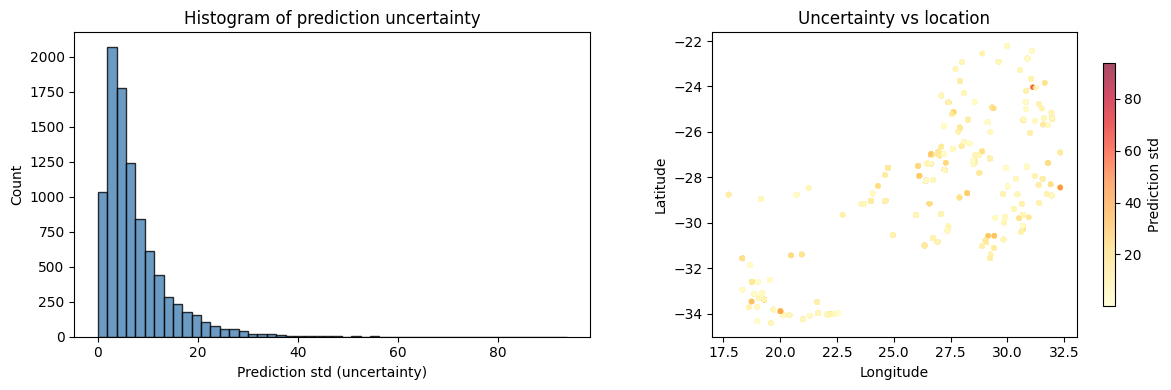

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prediction_std, bins=50, color="steelblue", edgecolor="k", alpha=0.8)
axes[0].set_xlabel("Prediction std (uncertainty)")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram of prediction uncertainty")

sc = axes[1].scatter(lon_arr, lat_arr, c=prediction_std, s=8, cmap="YlOrRd", alpha=0.7)
plt.colorbar(sc, ax=axes[1], label="Prediction std", shrink=0.8)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title("Uncertainty vs location")
axes[1].set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

# 5. Error vs uncertainty

Compare **prediction error** (|observed − mean_prediction|) with **estimated uncertainty** (prediction_std). Check whether larger uncertainty corresponds to higher prediction error.

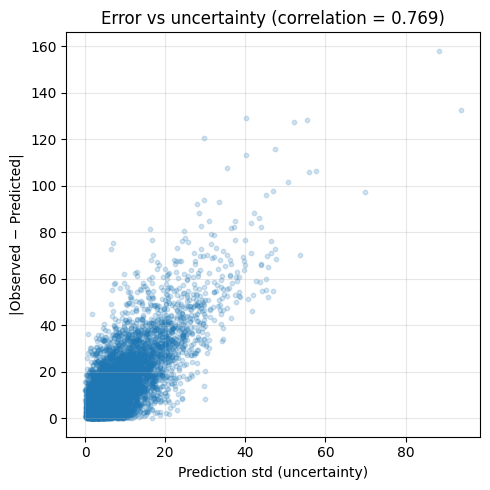

Correlation between uncertainty and absolute error: 0.7688
Positive correlation: higher ensemble spread tends to co-occur with larger errors.


In [5]:
prediction_error = np.abs(y - mean_prediction)
corr = np.corrcoef(prediction_std, prediction_error)[0, 1]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(prediction_std, prediction_error, alpha=0.2, s=10)
ax.set_xlabel("Prediction std (uncertainty)")
ax.set_ylabel("|Observed − Predicted|")
ax.set_title(f"Error vs uncertainty (correlation = {corr:.3f})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlation between uncertainty and absolute error: {corr:.4f}")
if corr > 0.2:
    print("Positive correlation: higher ensemble spread tends to co-occur with larger errors.")
else:
    print("Weak or no correlation: ensemble spread may not fully reflect prediction error (e.g. in-sample).")

# 6. Interpretation

## Regions with unreliable predictions
- **High prediction_std** on the map indicates locations where the ensemble **disagrees**: different models give different predictions. Those areas are **less reliable** for decision-making (e.g. extrapolation, rare environments, or conflicting predictor relationships).
- Use the uncertainty map to flag **priority areas for new sampling** or to avoid over-interpreting predictions where std is large.

## Implications for environmental monitoring
- **Uncertainty** (ensemble spread) is a **proxy** for reliability: it does not replace proper validation (e.g. spatial CV) but helps identify where the model is less confident.
- If **error and uncertainty are positively correlated**, the ensemble spread is somewhat **calibrated**: higher uncertainty often means higher error. If not, uncertainty may underestimate or overestimate true error (e.g. when all models are similarly wrong).
- For **monitoring**, report **mean_prediction ± prediction_std** or use percentiles across models where appropriate; prioritize actions in low-uncertainty regions and treat high-uncertainty zones as candidates for further data collection or conservative interpretation.